# **Reversal Signals**

The strategy buys recent losers to investigate short-lived selling pressure and subsequent reversal. This notebook is the final **2024–2025 evaluation and  risk comparison**. 5% target cap kept as a candidate for forward testing. At this point, we have not proved an edge.

This notebook is a summary of the [complete research archive](archive/reversal_signals_uk_research_2026_09_15.ipynb), which preserves the original code, outputs, development sweeps, holdout work, and event investigations.

## Evidence and scope
The benchmark throughout this project is the strategy of buying equal weighting across the universe, with trading sessions being at precisely the same time as the reversal signal strategy.

| Evaluation | Days tested | Average daily net benchmark excess | One-sided p-value | Interpretation |
|---|---:|---:|---:|---|
| 2017–2021 development walk-forward | 1,206 | 21.120 bps | 0.00001075 | Saved development diagnostic. in old notebook |
| 2022–2023 original holdout | 501 | 6.187 bps | 0.238007 | Saved original holdout. in old notebook |
| 2024–2025 original extension | 507 | 5.269 bps | 0.188848 | Reproduced below on (corrected) extension data |


These are historical records of different evaluations, not one continuous validated equity curve. The earlier mean was much larger and the sample was longer. Later data preparation also corrected historical prices, actions and suspensions; the 2017–2021 result has **not** been recalculated on that new data version. Regime changes, selection effects and data differences are plausible explanations, not established causes. A significant earlier test does not guarantee a significant later test, and different significance labels alone do not establish a statistically significant difference between periods.

The final risk comparison was chosen after inspecting 2024–2025. It remains exploratory even if a test passes. Its Holm correction covers the nine final comparisons, not all decisions made throughout this research.

## Setup and frozen inputs

In [1]:
import hashlib
import importlib
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

_HERE = Path.cwd().resolve()
_REPO_ROOT = next(
    directory for directory in (_HERE, *_HERE.parents)
    if (directory / "reversal_signals" / "src").is_dir()
)
_PORTFOLIO_ROOT = next(
    directory for directory in (_REPO_ROOT, *_REPO_ROOT.parents)
    if (directory / "original_portfolio").is_dir()
)
for project_name in ("reversal_signals", "risk_management"):
    for source_path in _PORTFOLIO_ROOT.glob(f"*/{project_name}/src"):
        if str(source_path) not in sys.path:
            sys.path.insert(0, str(source_path))
if str(_PORTFOLIO_ROOT.parent) not in sys.path:
    sys.path.append(str(_PORTFOLIO_ROOT.parent))
import trading_portfolio
if str(_REPO_ROOT) not in list(trading_portfolio.__path__):
    #a plain list survives sys.path changes; a namespace path is recalculated and would drop this
    trading_portfolio.__path__ = [*trading_portfolio.__path__, str(_REPO_ROOT)]

import reversal_features
import reversal_validation
import plotting_reversal_signals
from reversal_risk.reporting import build_final_report

In [2]:
import importlib
import reversal_preparation

importlib.reload(reversal_preparation)
uk_extension_data = reversal_preparation.prepare_uk_extension(
    _REPO_ROOT / "reversal_signals",
)

uk_extension_prices = uk_extension_data["prices"]
uk_extension_market = uk_extension_data["market"]
uk_extension_schedule = uk_extension_data["schedule"]
uk_extension_frozen_spec = uk_extension_data["manifest"]["frozen_strategy"]

display(pd.Series(uk_extension_data["manifest"]["summary"], name="Prepared data"))


/Users/oscarlewis/Desktop/python/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


declared_tickers                         646
available_tickers                        573
unavailable_tickers                       73
sessions                                2779
evaluation_sessions                      507
rows                                 1592367
suspended_rows                          4105
quarantined_quotes                       269
observed_rows                        1317566
ohlc_consistency_flags                302068
extreme_close_ratios                      19
stage                     ready_for_features
Name: Prepared data, dtype: object

The declared catalogue contains 646 candidates; the corrected preparation snapshot supplies 573 histories and leaves 73 unavailable. Daily eligibility further requires a 60-session liquidity history, at least £100,000 median daily traded-value proxy, at most 5% zero-volume sessions, positive signal-day volume, and a complete formation window. This is a present-day catalogue with historical availability filters, not a reconstructed historical broker membership universe.

In [3]:
display(uk_extension_data["corrections"])
display(uk_extension_schedule.groupby(uk_extension_schedule.index.year).size().rename("LSE sessions"))

print("Available tickers remain subject to the existing daily eligibility rules.")
print("Preparation is cached; no download, signal or portfolio calculation runs here.")
print("Documented suspensions and reviewed unreliable quotes are unavailable for execution.")
print("Yahoo quotes, incomplete suspension coverage and present-day membership remain data limits.")


Available tickers remain subject to the existing daily eligibility rules.
Preparation is cached; no download, signal or portfolio calculation runs here.
Documented suspensions and reviewed unreliable quotes are unavailable for execution.
Yahoo quotes, incomplete suspension coverage and present-day membership remain data limits.


,ticker,change,factor,note
0,CHL.L,historical price-unit correction,100.000000,Cash dividends and share volumes were already ...
1,DISH.L,historical price-unit correction,100.000000,Cash dividends and share volumes were already ...
2,ELEG.L,historical price-unit correction,100.000000,Cash dividends and share volumes were already ...
3,GCG.L,historical price-unit correction,100.000000,Cash dividends and share volumes were already ...
4,HSM.L,historical price-unit correction,100.000000,Cash dividends and share volumes were already ...
5,PCH.L,historical price-unit correction,100.000000,Cash dividends and share volumes were already ...
6,SAVE.L,historical price-unit correction,100.000000,Cash dividends and share volumes were already ...
7,TIN.L,ten old shares per new synthetic share,10.000000,Price x10 and volume /10 preserve traded value.
8,AST.L,"2015 consolidation: 1-for-20, not vendor 1-for-2",10.000000,Pre-event price x10 and volume /10; cash value...
9,RFG.L,"missing GBP 1.66 capital return, ex-date 2021-...",0.056818,Cash entitlement and exact total-return adjust...


Date
2015    253
2016    253
2017    252
2018    253
2019    253
2020    254
2021    253
2022    250
2023    251
2024    254
2025    253
Name: LSE sessions, dtype: int64

## Features and daily eligibility

Scores use adjusted closing returns and are timestamped at the close. Common eligibility covers all four formation windows, so configurations use the same stock-date availability. Liquidity estimates use prior sessions. No forward return enters eligibility or ranking.

In [4]:
uk_extension_rules = uk_extension_frozen_spec["eligibility"]

uk_extension_activity = uk_extension_prices[["ticker", "Close", "Volume"]].copy()

#prices already in GBP
uk_extension_activity["traded_value_proxy_gbp"] = uk_extension_activity["Close"] * uk_extension_activity["Volume"]

#preserve missing volume as missing, as opposed to zero
uk_extension_activity["reported_zero_volume"] = uk_extension_activity["Volume"].eq(0).astype(float).where(uk_extension_activity["Volume"].notna())

uk_extension_liquidity = (
    reversal_features.build_liquidity_features(
        uk_extension_activity,
        uk_extension_schedule,
        lookback=uk_extension_rules["liquidity_lookback_sessions"],
    ).set_index("ticker", append=True).sort_index())

display(uk_extension_liquidity.loc[uk_extension_liquidity["history_ready"]].head())

lookback_sessions  ...  history_ready
Date       ticker                     ...               
2015-03-27 80M.L                  60  ...           True
           88E.L                  60  ...           True
           AAU.L                  60  ...           True
           AAZ.L                  60  ...           True
           ABDP.L                 60  ...           True

[5 rows x 5 columns]

In [ ]:
uk_extension_grid = (pd.DataFrame(uk_extension_frozen_spec["configuration_grid"]).set_index("configuration_id").sort_index())
uk_extension_formation_windows = sorted(uk_extension_grid["formation_sessions"].unique().tolist())

uk_extension_features = {}
for lookback in uk_extension_formation_windows:
    uk_extension_features[lookback] = (reversal_features.build_raw_reversal_features(
            uk_extension_prices,
            uk_extension_schedule,
            lookback=int(lookback)
        ).set_index("ticker", append=True).sort_index())

print("Formation windows:", uk_extension_formation_windows)
display(uk_extension_features[5][["raw_return", "raw_reversal_score"]].dropna().head())

Formation windows: [1, 3, 5, 10]


raw_return  raw_reversal_score
Date       ticker                                
2015-01-09 80M.L     0.000000           -0.000000
           88E.L     0.000000           -0.000000
           AAU.L    -0.028571            0.028571
           AAZ.L    -0.094340            0.094340
           ABDP.L    0.003225           -0.003225

In [6]:
uk_extension_keyed_prices = uk_extension_prices.set_index("ticker", append=True).sort_index()
valid_close = (np.isfinite(uk_extension_keyed_prices["adj_close"]) & uk_extension_keyed_prices["adj_close"].gt(0))

#10 session returns needs 11 consecutive observations
window = max(uk_extension_formation_windows) + 1

complete_window = valid_close.groupby(level="ticker", sort=False).transform(
    lambda values: values.rolling(window, min_periods=window).sum().eq(window))

uk_extension_eligible = (uk_extension_liquidity["history_ready"] & uk_extension_liquidity["median_traded_value_gbp"].ge(uk_extension_rules["min_median_traded_value_gbp"])
    & uk_extension_liquidity["zero_volume_fraction"].le(uk_extension_rules["max_zero_volume_fraction"]))

if uk_extension_rules["require_complete_formation_window"]:
    uk_extension_eligible &= complete_window

if uk_extension_rules["require_positive_signal_day_volume"]:
    uk_extension_eligible &= (np.isfinite(uk_extension_keyed_prices["Volume"]) & uk_extension_keyed_prices["Volume"].gt(0))
for panel in uk_extension_features.values():
    uk_extension_eligible &= np.isfinite(panel["raw_reversal_score"])
for panel in uk_extension_features.values():
    panel["eligible"] = uk_extension_eligible

uk_extension_eligible_counts = uk_extension_eligible.groupby(level="Date").sum().rename("eligible_stocks")

display(uk_extension_eligible_counts.groupby(uk_extension_eligible_counts.index.year).agg(["min", "median", "max"]))

,min,median,max
Date,,,
2015,0,51.0,56
2016,44,54.0,66
2017,26,75.0,90
2018,48,90.0,100
2019,71,84.0,101
2020,70,110.0,139
2021,138,162.0,198
2022,105,136.0,164
2023,100,112.0,139


## Frozen walk-forward selection

The 36 raw-reversal configurations combine 1/3/5/10 formation sessions, top 10/20/30%, and 1/3/5 holding sessions. The selector starts with 504 training sessions, expands its training history, and reviews every 63 sessions. Selection uses mean daily net benchmark excess at 10 bps per side and only outcomes available by the selection date. All nine reviews covering this extension select configuration 27: 10-session formation, top 10%, one-session holding.

The calculations below retain the frozen adaptive selector; they do not replace it with a retrospectively fixed configuration.

In [7]:
uk_extension_sessions = uk_extension_schedule.index
uk_extension_positions = np.arange(len(uk_extension_sessions))
uk_extension_decision_dates = {}

for holding in sorted(uk_extension_grid["holding_sessions"].unique()):
    holding = int(holding)

    calendar = reversal_validation.build_rebalance_calendar(
        uk_extension_schedule,
        anchor=pd.Timestamp(uk_extension_frozen_spec["rebalance_anchor"]),
        rebalance_sessions=holding
    )

    #allow next-open entry and full holding period before data end
    complete_horizon = (uk_extension_positions + 1 + holding < len(uk_extension_sessions))

    uk_extension_decision_dates[holding] = (uk_extension_sessions[calendar["is_rebalance"].to_numpy() & complete_horizon])

display(pd.DataFrame([{
            "holding_sessions": holding,
            "first_signal": dates[0],
            "last_signal": dates[-1],
            "signal_dates": len(dates)
        } for holding, dates in uk_extension_decision_dates.items()]).set_index("holding_sessions"))

,first_signal,last_signal,signal_dates
holding_sessions,,,
1,2015-03-27,2025-12-29,2717
3,2015-03-27,2025-12-19,905
5,2015-03-27,2025-12-17,543


In [8]:
import hashlib
import json

signature = hashlib.sha256(json.dumps({"spec": uk_extension_frozen_spec,
            "prepared_inputs": uk_extension_data["manifest"]["input_sha256"],
            "pandas_version": pd.__version__,
            "cache_version": 1},
            sort_keys=True).encode())

for frame in [uk_extension_market, uk_extension_schedule, uk_extension_grid, *uk_extension_features.values()]:
    signature.update(pd.util.hash_pandas_object(frame, index=True).to_numpy().tobytes())

for holding, dates in sorted(uk_extension_decision_dates.items()):
    signature.update(str(holding).encode())
    signature.update(dates.asi8.tobytes())

uk_extension_candidate_cache = (_REPO_ROOT / "reversal_signals" / "data" / "uk_extension_2023_2025_v1" / "candidate_returns" / signature.hexdigest()[:20])
if not uk_extension_candidate_cache.is_dir():
    raise FileNotFoundError("The frozen candidate cache is missing; restore the reviewed inputs before running.")

In [ ]:
uk_extension_expected_returns = uk_extension_schedule.loc[uk_extension_frozen_spec["rebalance_anchor"]:].index[1:]
uk_extension_candidate_returns = {}

for configuration in uk_extension_grid.itertuples():
    configuration_id = int(configuration.Index)
    path = uk_extension_candidate_cache / f"configuration_{configuration_id:02d}.pkl"
    if not path.is_file():
        raise FileNotFoundError(f"Missing reviewed candidate cache: {path}")
    excess = pd.read_pickle(path)
    pd.testing.assert_index_equal(excess.index, uk_extension_expected_returns)
    if not np.isfinite(excess.to_numpy()).all():
        raise ValueError(f"Unknown returns for configuration {configuration_id}.")
    uk_extension_candidate_returns[configuration_id] = excess

uk_extension_net_excess = pd.DataFrame(uk_extension_candidate_returns).rename_axis(columns="configuration_id")
print("Loaded configuration return panel:", uk_extension_net_excess.shape)

Loaded configuration return panel: (2718, 36)


In [103]:
import reversal_walk_forward

uk_extension_wf_rules = uk_extension_frozen_spec["walk_forward"]
uk_extension_folds = (reversal_walk_forward.build_walk_forward_folds(
        uk_extension_net_excess,
        uk_extension_schedule,
        initial_train_sessions=uk_extension_wf_rules["initial_train_sessions"], 
        test_sessions=uk_extension_wf_rules["test_sessions"]))

uk_extension_choices = (reversal_walk_forward.select_walk_forward_configurations(
        uk_extension_net_excess,
        uk_extension_folds,
        uk_extension_grid,
        uk_extension_wf_rules
    ))

print("Total folds:", len(uk_extension_folds))
display(uk_extension_choices.loc[uk_extension_choices["test_end"].ge(pd.Timestamp("2024-01-01")),[
            "selection_date",
            "configuration_id",
            "formation_sessions",
            "top_frac",
            "holding_sessions",
            "best_training_mean_bps",
            "allow_new_entries"
        ]])

Total folds: 36


,selection_date,configuration_id,formation_sessions,top_frac,holding_sessions,best_training_mean_bps,allow_new_entries
fold,,,,,,,
27,2023-12-19,27,10,0.1,1,19.240206,True
28,2024-03-20,27,10,0.1,1,18.479048,True
29,2024-06-21,27,10,0.1,1,18.376779,True
30,2024-09-19,27,10,0.1,1,18.047340,True
31,2024-12-17,27,10,0.1,1,17.648634,True
32,2025-03-19,27,10,0.1,1,17.391223,True
33,2025-06-20,27,10,0.1,1,16.751393,True
34,2025-09-18,27,10,0.1,1,16.741688,True
35,2025-12-16,27,10,0.1,1,16.654865,True


## Original extension: execution and inference

Each simulation starts with £10,000 cash at the final 2023 session close. Decisions made after a close trade at the following open; the original selection calendar therefore makes its first trade on 2 January 2024. Opening prices are assumed fills, net orders avoid unnecessary sell-and-rebuy trades, and transaction costs are 10 bps per side on the executed notional. Dividends are reserved separately at entitlement and are not reinvested. Invalid or suspended opening quotes can block orders.

The benchmark equally weights eligible stocks at the strategy's planned invested exposure. It is a rebalanced comparison, not a passive market index. This section reproduces the original extension with zero cash interest; interest is introduced consistently for all risk comparisons below.

In [11]:
uk_extension_eval_start = pd.Timestamp("2024-01-01")
uk_extension_cash_date = uk_extension_sessions[uk_extension_sessions < uk_extension_eval_start][-1]
uk_extension_eval_choices = uk_extension_choices.loc[uk_extension_choices["test_end"] >= uk_extension_eval_start].copy()

uk_extension_decisions = (reversal_walk_forward.build_walk_forward_decisions(
        uk_extension_eval_choices,
        uk_extension_features,
        uk_extension_decision_dates,
        min_eligible=uk_extension_frozen_spec["minimum_eligible"]).loc[uk_extension_cash_date:].copy())


#ensure valuation starts from cash even if this isnt a rebalance date
if uk_extension_cash_date not in (
    uk_extension_decisions.index.get_level_values("Date")):
    cash_marker = (uk_extension_features[min(uk_extension_formation_windows)].xs(uk_extension_cash_date, level="Date", drop_level=False)
        [["signal_time", "eligible"]].copy().assign(
            eligible=False,
            selected=False,
            target_weight=0.0,
            holding_sessions=1
    ))
    uk_extension_decisions = pd.concat([cash_marker, uk_extension_decisions]).sort_index()

uk_extension_holding_lengths = uk_extension_decisions.groupby(level="Date")["holding_sessions"].first().astype("int64")
uk_extension_benchmark_decisions = uk_extension_decisions[["signal_time", "eligible"]].copy()
counts = uk_extension_benchmark_decisions["eligible"].groupby(level="Date").transform("sum")
exposure = uk_extension_decisions["target_weight"].groupby(level="Date").transform("sum")

uk_extension_benchmark_decisions["target_weight"] = (uk_extension_benchmark_decisions["eligible"]
    .astype(float).mul(exposure).div(counts.where(counts.gt(0))).fillna(0.0))

In [12]:
import reversal_backtest

uk_extension_eval_schedule = uk_extension_schedule.loc[uk_extension_cash_date:]
uk_extension_eval_market = uk_extension_market.loc[uk_extension_cash_date:]

uk_extension_results = {}

for name, decisions in {
    "Walk-forward": uk_extension_decisions,
    "Matched benchmark": uk_extension_benchmark_decisions}.items():
    result = reversal_backtest.run_execution_backtest(
        decisions=decisions,
        market=uk_extension_eval_market,
        schedule=uk_extension_eval_schedule,
        initial_capital_gbp=uk_extension_frozen_spec["initial_capital_gbp"],
        cost_per_side_bps=uk_extension_wf_rules["cost_per_side_bps"],
        net_orders=True,
        holding_sessions_by_date=uk_extension_holding_lengths
    )

    pd.testing.assert_index_equal(result["daily"].index, uk_extension_eval_schedule.index)
    uk_extension_results[name] = result

uk_extension_equity = pd.DataFrame({
    name: result["daily"]["equity_gbp"]
    for name, result in uk_extension_results.items()})

if not np.isfinite(uk_extension_equity.to_numpy()).all():
    raise ValueError("Resolve unknown portfolio values before reporting.")

assert uk_extension_equity.iloc[0].eq(10_000).all()
assert len(uk_extension_equity) == 508  # Initial cash row + 507 sessions.

display(uk_extension_equity.iloc[[0, -1]].round(2))
display(pd.DataFrame({name: {
        "costs_gbp": result["daily"]["cost_gbp"].sum(),
        "final_stale_value_gbp": result["daily"]["stale_value_gbp"].iloc[-1],
        "remaining_positions": len(result["final_positions"])
    } for name, result in uk_extension_results.items()}).T.round(2))

,Walk-forward,Matched benchmark
Date,,
2023-12-29,10000.00,10000.00
2025-12-31,12713.81,10266.48


,costs_gbp,final_stale_value_gbp,remaining_positions
Walk-forward,3513.55,0.0,0.0
Matched benchmark,200.37,0.0,0.0


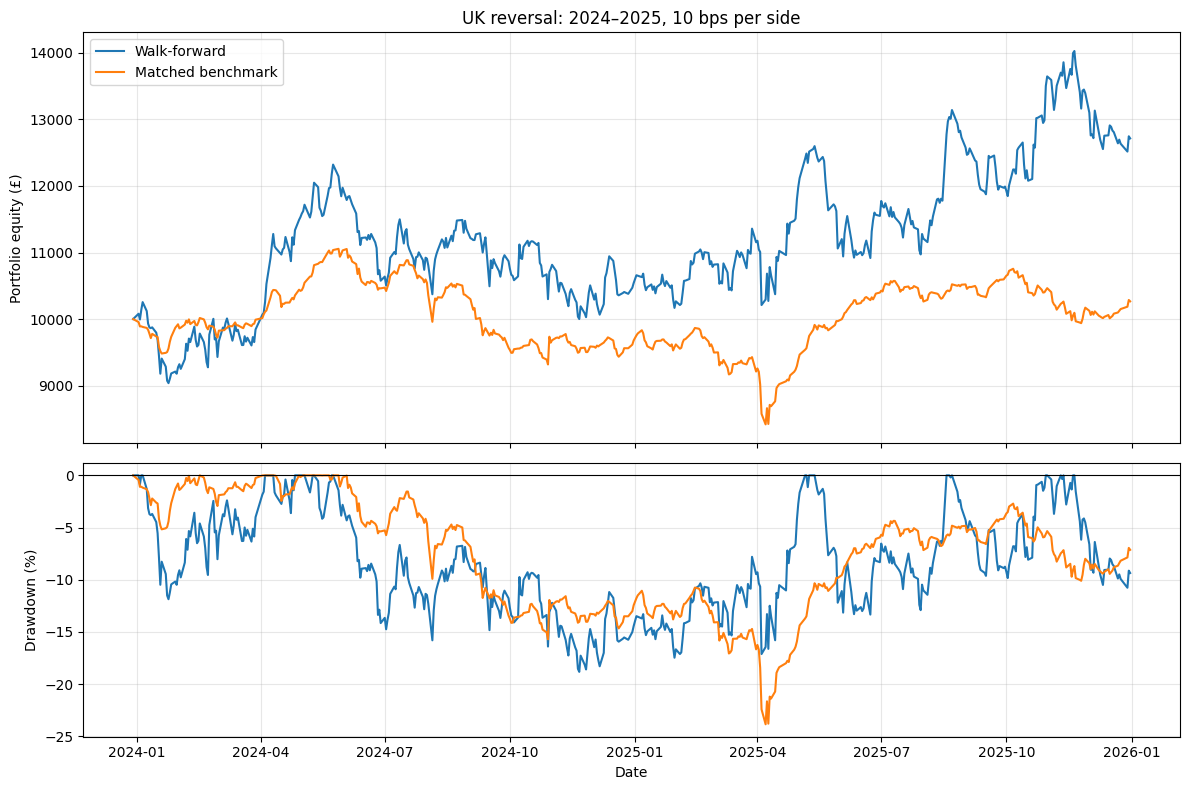

In [13]:
import plotting_reversal_signals

uk_extension_figure = (plotting_reversal_signals.plot_equity_and_drawdown(uk_extension_equity, title="UK reversal: 2024–2025, 10 bps per side", log_equity=False))

In [14]:
#daily returns from both portfolios, net of modelled costs
uk_extension_paired_returns = (uk_extension_equity.pct_change(fill_method=None).iloc[1:])
uk_extension_wf_net_excess = (uk_extension_paired_returns["Walk-forward"] - uk_extension_paired_returns["Matched benchmark"]
).to_frame("walk_forward_extension").rename_axis(columns="configuration_id")

#retain each evaluation session
pd.testing.assert_index_equal(uk_extension_wf_net_excess.index, uk_extension_eval_schedule.index[1:])
if not np.isfinite(uk_extension_wf_net_excess.to_numpy()).all():
    raise ValueError("Resolve unknown evaluation returns before inference.")

uk_extension_inference = reversal_validation.infer_sweep_means(
    net_returns=uk_extension_wf_net_excess,
    grid=pd.DataFrame(index=uk_extension_wf_net_excess.columns),
    rules=uk_extension_frozen_spec["primary_inference"])

display(uk_extension_inference[[
            "periods",
            "mean_bps",
            "hac_se_bps",
            "ci_lower_bps",
            "ci_upper_bps",
            "p_one_sided",
            "reject_holm" ]])

,periods,mean_bps,hac_se_bps,ci_lower_bps,ci_upper_bps,p_one_sided,reject_holm
configuration_id,,,,,,,
walk_forward_extension,507,5.268836,5.97272,-6.437479,16.975152,0.188848,False


## Concentration and event diagnostics

Large positive and negative stock-specific days drive much of the variation. The best five days account for about 95% of the original sum of daily excess returns; this is a concentration diagnostic, not a reason to delete those days. The archive contains full WSBN and CHAR event investigations. Their announcements illustrate that ordinary volatility and permanent information shocks can dominate a liquidity-reversal signal.

In [ ]:
uk_extension_calendar_returns = {}

for period, groups in {"year": uk_extension_paired_returns.index.year,
    "month": uk_extension_paired_returns.index.to_period("M")}.items():

    #compound each portfolio seperately within each period

    summary = (uk_extension_paired_returns.add(1).groupby(groups).prod()
        .sub(1).mul(100).rename_axis(period).rename(columns={
            "Walk-forward": "strategy_return_pct",
            "Matched benchmark": "benchmark_return_pct",
        }))

    summary["excess_return_pp"] = summary["strategy_return_pct"] - summary["benchmark_return_pct"]

    #same measure used in primary test
    summary["mean_daily_net_excess_bps"] = (uk_extension_wf_net_excess["walk_forward_extension"]
        .groupby(groups).mean().mul(10_000))

    uk_extension_calendar_returns[period] = summary
    if period == "year":
        display(summary.round(2))
print("Months outperforming:", int(uk_extension_calendar_returns["month"]["excess_return_pp"].gt(0).sum()), "of", len(uk_extension_calendar_returns["month"]))

Months outperforming: 13 of 24


,strategy_return_pct,benchmark_return_pct,excess_return_pp,mean_daily_net_excess_bps
year,,,,
2024,5.42,-3.20,8.62,4.33
2025,20.60,6.06,14.54,6.21


In [16]:
uk_extension_daily_contributions = (uk_extension_paired_returns.mul(10_000).rename(columns={
        "Walk-forward": "strategy_return_bps",
        "Matched benchmark": "benchmark_return_bps"
        }))

uk_extension_daily_contributions["net_excess_bps"] = uk_extension_wf_net_excess["walk_forward_extension"] * 10_000
uk_extension_ranked_excess = uk_extension_daily_contributions["net_excess_bps"].sort_values(ascending=False, kind="stable")
uk_extension_concentration_rows = []
total_excess = uk_extension_ranked_excess.sum()
n_days = len(uk_extension_ranked_excess)

for k in [1, 5, 10, 20]:
    top_sum = uk_extension_ranked_excess.iloc[:k].sum()

    uk_extension_concentration_rows.append({
        "top_days": k,
        "share_of_total_net_excess_pct": (100 * top_sum / total_excess if total_excess != 0 else np.nan),
        "top_days_contribution_to_mean_bps": top_sum / n_days,
        "other_days_contribution_to_mean_bps": (total_excess - top_sum) / n_days,
    })

uk_extension_concentration = pd.DataFrame(uk_extension_concentration_rows).set_index("top_days")

display(uk_extension_concentration.round(2))
print("Strongest days relative to the benchmark:")
display(uk_extension_daily_contributions.nlargest(10, "net_excess_bps").round(2))

print("Weakest days relative to the benchmark:")
display(uk_extension_daily_contributions.nsmallest(10, "net_excess_bps").round(2))

Strongest days relative to the benchmark:
Weakest days relative to the benchmark:


,share_of_total_net_excess_pct,top_days_contribution_to_mean_bps,other_days_contribution_to_mean_bps
top_days,,,
1,27.96,1.47,3.80
5,94.78,4.99,0.27
10,158.66,8.36,-3.09
20,263.41,13.88,-8.61


,strategy_return_bps,benchmark_return_bps,net_excess_bps
Date,,,
2025-08-18,845.97,99.01,746.96
2024-02-23,528.46,56.89,471.57
2025-10-21,426.99,-34.57,461.55
2024-10-08,449.67,-0.35,450.02
2025-04-23,430.53,28.65,401.87
2025-10-30,398.32,29.49,368.83
2024-12-10,392.28,28.20,364.08
2024-09-17,369.98,43.09,326.88
2025-06-24,365.69,41.12,324.57


,strategy_return_bps,benchmark_return_bps,net_excess_bps
Date,,,
2024-09-16,-654.36,-112.92,-541.44
2025-05-30,-484.52,-1.61,-482.91
2025-06-09,-309.99,81.76,-391.75
2025-04-14,-266.64,85.32,-351.96
2024-07-15,-315.68,-7.60,-308.08
2024-06-26,-355.82,-71.72,-284.10
2024-05-14,-258.13,16.96,-275.09
2025-11-24,-290.40,-19.11,-271.29
2024-10-29,-349.16,-77.94,-271.22


In [ ]:
uk_extension_stock_attribution = {}

for name, result in uk_extension_results.items():
    uk_extension_stock_attribution[name] = (reversal_validation.attribute_stock_pnl(
            result=result,
            market=uk_extension_eval_market,
            initial_capital_gbp=uk_extension_frozen_spec["initial_capital_gbp"]
        ))

#stock never traded by a portfolio contributes 0
uk_extension_stock_comparison = pd.DataFrame({name: attribution["net_pnl_gbp"] for name, attribution in uk_extension_stock_attribution.items()}).fillna(0.0)

uk_extension_stock_comparison["wealth_difference_gbp"] = uk_extension_stock_comparison["Walk-forward"] - uk_extension_stock_comparison["Matched benchmark"]

#contributions must account for final wealth difference
np.testing.assert_allclose(uk_extension_stock_comparison["wealth_difference_gbp"].sum(),
    (uk_extension_equity["Walk-forward"].iloc[-1] - uk_extension_equity["Matched benchmark"].iloc[-1]), rtol=1e-10, atol=1e-6)

print("Largest contributions to outperformance:")
display(uk_extension_stock_comparison.nlargest(10, "wealth_difference_gbp").round(2))

print("Largest detractors:")
display(uk_extension_stock_comparison.nsmallest(10, "wealth_difference_gbp").round(2))

print("Reconciled final-wealth difference (£):",round(uk_extension_stock_comparison["wealth_difference_gbp"].sum(), 2))

Largest contributions to outperformance:
Largest detractors:
Reconciled final-wealth difference (£): 2447.34


,Walk-forward,Matched benchmark,wealth_difference_gbp
ticker,,,
WSBN.L,1176.73,135.02,1041.71
BOOM.L,627.97,85.11,542.86
EPP.L,350.80,-115.44,466.24
FTC.L,590.31,124.68,465.64
PRD.L,483.67,27.66,456.01
GGP.L,493.68,80.68,413.00
NFG.L,348.95,-35.35,384.30
BCE.L,365.60,3.86,361.75
MTL.L,438.10,78.27,359.83


,Walk-forward,Matched benchmark,wealth_difference_gbp
ticker,,,
HE1.L,-1024.27,254.99,-1279.26
PANR.L,-833.86,-3.89,-829.97
MET1.L,-707.98,-137.67,-570.31
VCP.L,-568.34,-52.10,-516.24
AVCT.L,-532.31,-18.78,-513.53
JOG.L,-515.68,-91.10,-424.58
PREM.L,-545.28,-145.73,-399.55
ITM.L,-351.91,39.25,-391.16
QBT.L,-299.03,-16.98,-282.05


In [18]:
uk_extension_position_risk = (uk_extension_results["Walk-forward"]["holdings"][["value_gbp", "stale_mark"]].copy())

holding_dates = (uk_extension_position_risk.index.get_level_values("Date"))
uk_extension_position_risk["weight_pct"] = (100 * uk_extension_position_risk["value_gbp"] / uk_extension_equity["Walk-forward"].reindex(holding_dates).to_numpy())

uk_extension_largest_weight = (uk_extension_position_risk["weight_pct"].groupby(level="Date").max().reindex(uk_extension_equity.index, fill_value=0.0).rename("largest_stock_weight_pct"))

print("Largest stock weight at each close — distribution:")
display(uk_extension_largest_weight.describe(percentiles=[0.50, 0.90, 0.95, 0.99]).round(2))

print("Ten largest observed stock weights:")
display(uk_extension_position_risk.nlargest(10, "weight_pct").round(2))

Largest stock weight at each close — distribution:
Ten largest observed stock weights:


count    508.00
mean       7.71
std        0.99
min        0.00
50%        7.62
90%        8.76
95%        9.02
99%       10.40
max       12.46
Name: largest_stock_weight_pct, dtype: float64

,,value_gbp,stale_mark,weight_pct
Date,ticker,,,
2025-08-18,WSBN.L,1592.09,False,12.46
2024-03-04,VAST.L,1147.52,False,11.62
2024-09-17,CHAR.L,1233.18,False,11.33
2024-02-05,BCE.L,1052.96,False,11.20
2024-10-11,PREM.L,1186.89,False,10.71
2024-11-27,GEO.L,1063.87,False,10.42
2024-01-05,ENET.L,1043.42,False,10.17
2025-03-28,PRD.L,1153.32,False,10.15
2024-01-04,KOD.L,1011.83,False,9.98


## Exploratory risk comparison and cash interest

Three variants use the same stock selection and execution assumptions:

- **Original:** unchanged target allocations.
- **Capped:** each target budget is at most 5% of trading equity; the removed allocation stays in cash and is not redistributed. Closing weights can exceed 5% after a price jump.
- **Drawdown:** exposure scales linearly between a −10% soft limit and −25% hard limit on the original zero-interest reference equity. The reference continues while the managed portfolio holds cash, providing a re-entry signal. The following open implements the change; these limits do not guarantee a bound on realised drawdown.

Each variant gets its own benchmark with matching planned exposure. The 3.8% AER is a **fixed scenario**, not reconstructed historical broker rates. Interest compounds over calendar days using 365.25 days per year and the previous session's available cash, with fractional-penny precision. Dividend entitlements receive no interest because payment dates are unavailable. Cash-only opportunity cost uses the same calendar and rate. [Trading 212 interest calculation](https://helpcentre.trading212.com/hc/en-us/articles/15475153380637-What-is-interest-on-cash).

In [ ]:
UK_RISK_MAX_TARGET_WEIGHT = 0.05

uk_extension_risk_decisions = uk_extension_decisions.copy()
uk_extension_risk_decisions["target_weight"] = uk_extension_risk_decisions["target_weight"].clip(upper=UK_RISK_MAX_TARGET_WEIGHT)

#match benchmark to capped strategy's planned exposure
uk_extension_risk_benchmark_decisions = uk_extension_risk_decisions[["signal_time", "eligible"]].copy()

eligible_counts = uk_extension_risk_benchmark_decisions["eligible"].groupby(level="Date").transform("sum")
capped_exposure = uk_extension_risk_decisions["target_weight"].groupby(level="Date").transform("sum")
uk_extension_risk_benchmark_decisions["target_weight"] = (uk_extension_risk_benchmark_decisions["eligible"].astype(float)
    .mul(capped_exposure).div(eligible_counts.where(eligible_counts.gt(0))).fillna(0.0))

baseline_invested = uk_extension_decisions["target_weight"].groupby(level="Date").sum()
capped_invested = uk_extension_risk_decisions["target_weight"].groupby(level="Date").sum()

uk_extension_risk_allocation = pd.DataFrame({
    "baseline_invested_pct": 100 * baseline_invested,
    "capped_invested_pct": 100 * capped_invested,
    "capped_unallocated_pct": 100 * (1 - capped_invested)
})

display(uk_extension_risk_allocation.describe().loc[["min", "50%", "max"]].round(2))

,baseline_invested_pct,capped_invested_pct,capped_unallocated_pct
min,100.0,55.0,10.0
50%,100.0,70.0,30.0
max,100.0,90.0,45.0


In [ ]:
from risk_limits import drawdown_trading_exposure

UK_DRAWDOWN_RULES = {
    "soft_limit": -0.10,
    "hard_limit": -0.25,
    "cash_aer": 0.038 #fixed interest rate
}

reference_equity = uk_extension_results["Walk-forward"]["daily"]["equity_gbp"]
reference_drawdown = reference_equity / reference_equity.cummax() - 1

uk_extension_breaker_signal = pd.DataFrame({
    "reference_drawdown": reference_drawdown,
    "target_exposure": drawdown_trading_exposure(reference_drawdown,
        soft_limit=UK_DRAWDOWN_RULES["soft_limit"],
        hard_limit=UK_DRAWDOWN_RULES["hard_limit"]
    )})

uk_extension_breaker_decisions = uk_extension_decisions.copy()
decision_dates = (uk_extension_breaker_decisions.index.get_level_values("Date"))
exposure_scale = uk_extension_breaker_signal["target_exposure"].reindex(decision_dates)

if exposure_scale.isna().any():
    raise ValueError("A decision date is missing its exposure signal.")


#decisions are already executed at following sessions open, dont shift exposure again.
uk_extension_breaker_decisions["target_weight"] *= (exposure_scale.to_numpy())
display(uk_extension_breaker_signal.describe().round(4))

,reference_drawdown,target_exposure
count,508.0000,508.0000
mean,-0.0853,0.9143
std,0.0482,0.1396
min,-0.1883,0.4113
25%,-0.1215,0.8567
50%,-0.0906,1.0000
75%,-0.0475,1.0000
max,0.0000,1.0000


In [ ]:
from reversal_risk import execution as reversal_risk_execution

importlib.reload(reversal_risk_execution)

#current extension selects one-session holdings throughout. longer holdings would need explicit early-exit rule
if not uk_extension_holding_lengths.eq(1).all():
    raise ValueError("This experiment currently assumes one-session holdings.")

uk_extension_interest_results = {}

for name, decisions in {
    "Original": uk_extension_decisions,
    "Capped": uk_extension_risk_decisions,
    "Drawdown": uk_extension_breaker_decisions
}.items():

    #give benchmark same planned exposure as its strategy
    benchmark_targets = decisions[["signal_time", "eligible"]].copy()
    eligible_count = (benchmark_targets["eligible"].groupby(level="Date").transform("sum"))
    planned_exposure = (decisions["target_weight"].groupby(level="Date").transform("sum"))

    benchmark_targets["target_weight"] = benchmark_targets["eligible"].astype(float).mul(planned_exposure).div(eligible_count.where(eligible_count.gt(0))).fillna(0.0)

    for label, targets in {name: decisions, f"{name} benchmark": benchmark_targets}.items():
        result = reversal_risk_execution.run_cash_interest_backtest(
            decisions=targets,
            market=uk_extension_eval_market,
            schedule=uk_extension_eval_schedule,
            initial_capital_gbp=uk_extension_frozen_spec["initial_capital_gbp"],
            cost_per_side_bps=uk_extension_wf_rules["cost_per_side_bps"],
            net_orders=True,
            holding_sessions_by_date=uk_extension_holding_lengths,
            cash_aer=UK_DRAWDOWN_RULES["cash_aer"]
        )

        pd.testing.assert_index_equal(result["daily"].index, uk_extension_eval_schedule.index)
        uk_extension_interest_results[label] = result

uk_extension_final_report = build_final_report(
    uk_extension_interest_results,
    rules=uk_extension_frozen_spec["primary_inference"],
    cash_aer=UK_DRAWDOWN_RULES["cash_aer"]
)
uk_extension_interest_equity = uk_extension_final_report["equity"]
uk_extension_interest_summary = uk_extension_final_report["summary"]
display(uk_extension_interest_summary.round(2))


,final_equity_gbp,total_return_pct,max_drawdown_pct,costs_gbp,cash_interest_gbp,final_stale_value_gbp,remaining_positions
Capped,12540.17,25.40,-12.84,2467.47,243.24,0.0,0.0
Capped benchmark,10484.55,4.85,-16.28,156.29,223.89,0.0,0.0
Cash only,10777.19,7.77,0.00,0.00,777.19,0.0,0.0
Drawdown,10906.19,9.06,-25.24,3080.09,67.38,0.0,0.0
Drawdown benchmark,9697.59,-3.02,-26.24,285.91,63.17,0.0,0.0
Original,12721.08,27.21,-18.83,3515.26,5.96,0.0,0.0
Original benchmark,10271.53,2.72,-23.85,200.46,4.90,0.0,0.0


## Final significance comparison

All nine hypotheses were declared before this final calculation: the original, capped and drawdown variants each against their matched benchmark, cash only, and zero return. The primary economic question is positive net matched-benchmark excess; cash and zero are secondary comparisons.

Every test uses all 507 evaluation returns, a one-sided mean test, Bartlett HAC standard errors with 20 lags and the finite-sample correction, and a normal reference distribution. Holm adjustment is applied once across all nine hypotheses. The 95% intervals below are **pointwise, two-sided** intervals, not simultaneous intervals. Raw p-values are retained so multiplicity adjustment cannot conceal the strength of the unadjusted evidence. These tests estimate average daily returns, not a probability of future profitability or a test of maximum drawdown.

In [ ]:
uk_extension_final_inference = uk_extension_final_report["inference"]
inference_columns = ["periods", "mean_bps", "hac_se_bps", "ci_lower_bps", "ci_upper_bps","p_one_sided", "p_holm_family", "reject_holm"]
print("Primary: excess over each variant's matched benchmark")
display(uk_extension_final_inference.loc[uk_extension_final_inference["role"].eq("primary"), inference_columns].round(4))
print("Secondary: excess over cash and return above zero")
display(uk_extension_final_inference.loc[uk_extension_final_inference["role"].eq("secondary"), inference_columns].round(4))
print("Tests passing Holm across the nine comparisons:", int(uk_extension_final_inference["reject_holm"].sum()))

Primary: excess over each variant's matched benchmark
Secondary: excess over cash and return above zero
Tests passing Holm across the nine comparisons: 0


,periods,mean_bps,hac_se_bps,ci_lower_bps,ci_upper_bps,p_one_sided,p_holm_family,reject_holm
configuration_id,,,,,,,,
Original vs matched benchmark,507,5.2705,5.9727,-6.4359,16.9769,0.1888,1.0,False
Capped vs matched benchmark,507,4.0742,4.4159,-4.5809,12.7293,0.1781,1.0,False
Drawdown vs matched benchmark,507,3.2200,5.7714,-8.0917,14.5318,0.2884,1.0,False


,periods,mean_bps,hac_se_bps,ci_lower_bps,ci_upper_bps,p_one_sided,p_holm_family,reject_holm
configuration_id,,,,,,,,
Original vs cash,507,4.5769,6.2877,-7.7467,16.9005,0.2333,1.0,False
Original vs zero,507,6.0533,6.2900,-6.2749,18.3815,0.1679,1.0,False
Capped vs cash,507,3.6602,4.5661,-5.2892,12.6096,0.2114,1.0,False
Capped vs zero,507,5.1366,4.5684,-3.8173,14.0906,0.1304,1.0,False
Drawdown vs cash,507,1.3372,6.1780,-10.7714,13.4458,0.4143,1.0,False
Drawdown vs zero,507,2.8136,6.1803,-9.2995,14.9267,0.3245,1.0,False


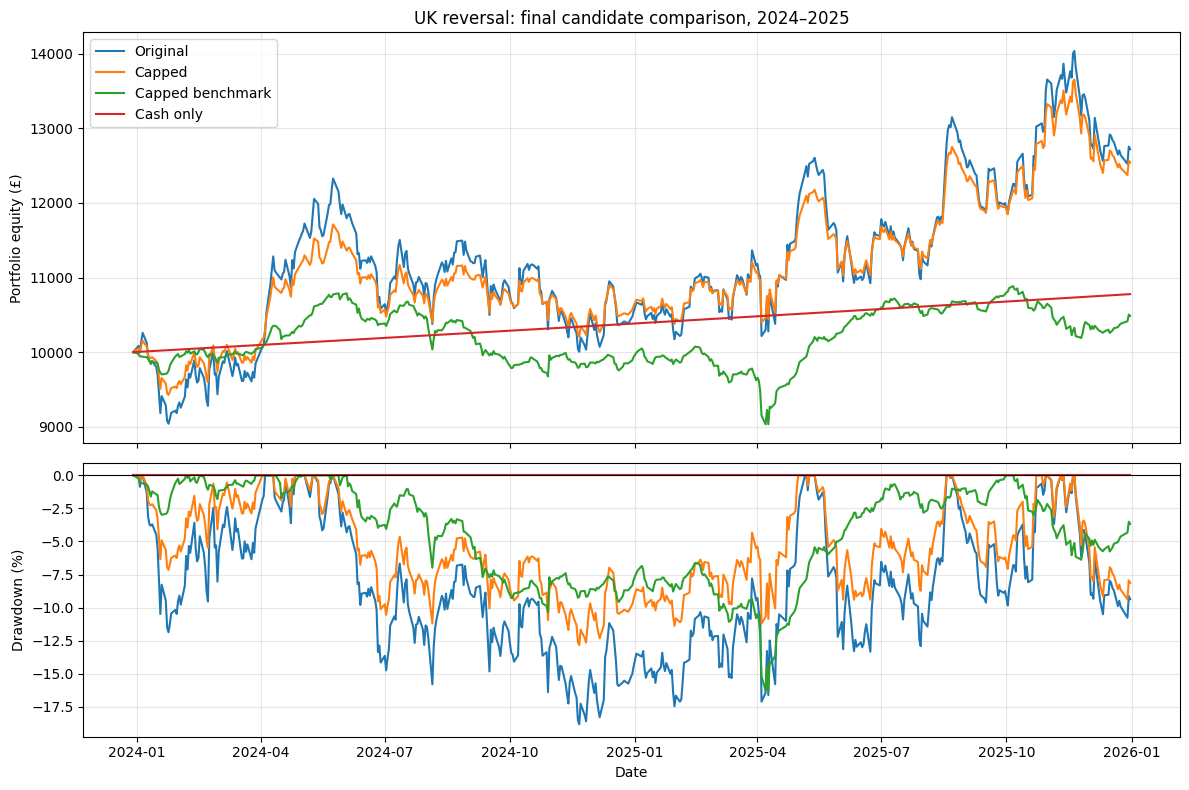

In [ ]:
uk_extension_final_figure = plotting_reversal_signals.plot_equity_and_drawdown(
    uk_extension_interest_equity[["Original", "Capped", "Capped benchmark", "Cash only"]],
    title="UK reversal: final candidate comparison, 2024–2025",
    log_equity=False
)

## Conclusion and research limits

The capped strategy finishes at **£12,540.17**, a **25.40%** total return, with **12.84%** maximum drawdown. The original with interest finishes at £12,721.08 with 18.83% drawdown; the cap therefore sacrifices £180.91 of terminal wealth while materially reducing the observed drawdown. Some benefit comes from holding more cash, as the capped benchmark also has lower drawdown.

The cap's mean daily net matched-benchmark excess is **4.074 bps**, with HAC standard error **4.416 bps**, pointwise 95% interval **[−4.581, 12.729] bps**, and one-sided p-value **0.1781**. Its p-values against cash and zero return are **0.2114** and **0.1304**. None of the nine tests passes even before correction. All Holm-adjusted p-values equal 1: the smallest raw p-value multiplied by nine already exceeds 1, so the first step clips at 1 and the subsequent monotone adjusted values remain 1.

The cap modestly improves the matched-excess test statistic relative to the original, but that is insufficient for significance. This is evidence of an attractive observed risk–return tradeoff under the model, with unresolved uncertainty about positive expected excess. The failed test does not prove the absence of an edge, and the historical terminal profit does not prove that an edge will repeat.

The research phase is complete. Retain the frozen adaptive selector with the 5% target cap as a forward-testing candidate, rather than add further risk variants to this already-inspected period. The core selector remains adaptive; configuration 27 was the outcome of the reviewed folds, not a new fixed live-trading instruction.

Limits that remain material:

- Historical membership is unavailable; the universe starts from a current broker catalogue and incomplete Yahoo histories.
- Spread, slippage, opening-auction participation and capacity are not verified by daily OHLCV data. The 10-bps-per-side assumption is a scenario, not a broker fee quote or execution guarantee.
- The reported QHE volume of 33 on 16 September 2024 remains inconsistent with an alternate historical source. Its precise replacement and any effect on eligibility/capacity remain unresolved; the frozen data were not silently changed.
- Dividend cash payment timing is unavailable, so the reserve remains outside trading and interest budgets.
- Historical results depend on the data version; earlier development and holdout results must not be combined with the corrected extension as though all used one consistent vintage.
- This final risk selection is exploratory. Fresh observations and an execution-quality review are needed before claiming a repeatable trading edge.

The research notebook and original frozen source bytes are archived. Active modules have had unused functions removed; retained strategy logic, prepared data values and candidate return series are unchanged. See the [source cleanup record](../data/source_cleanup_2026_09_15/README.md). Final tables, daily contrasts and a reproducibility manifest are saved alongside the review under `data/uk_final_review_2026_09_15/`.